## Task 2

**Choice of dataset**: [Kaggle: ECG Heartbeat Categorization Dataset](https://www.kaggle.com/datasets/shayanfazeli/heartbeat)

Each row represents ONE segmented heartbeat from a patient. Every row contains exactly 188 columns.

**Columns 1 through 187**: These are the sequential electrical voltage readings of the heartbeat over time.

**Column 188**: This is the target label (0 = Normal, 1 = Supraventricular premature beat, 2 = Premature ventricular contraction, 3 = Fusion of ventricular and normal beat, 4 = Unclassifiable beat).

Standard models look at all data points at once and don't care about the order. If you scrambled the columns, a standard model wouldn't know the difference.

But a heartbeat is a continuous wave. To spot an irregular heartbeat, the model needs to understand the shape and timing of that wave. A sequence model reads the data exactly how a doctor reads an ECG chart—left to right.


In [105]:
import pandas as pd
import matplotlib.pyplot as plt

#### EDA

In [106]:
df = pd.read_csv('mitbih_train.csv', header=None)

In [107]:
class_names = {
    0.0: 'Normal Beat',
    1.0: 'Supraventricular Premature',
    2.0: 'Premature Ventricular',
    3.0: 'Fusion Beat',
    4.0: 'Unclassifiable'
}

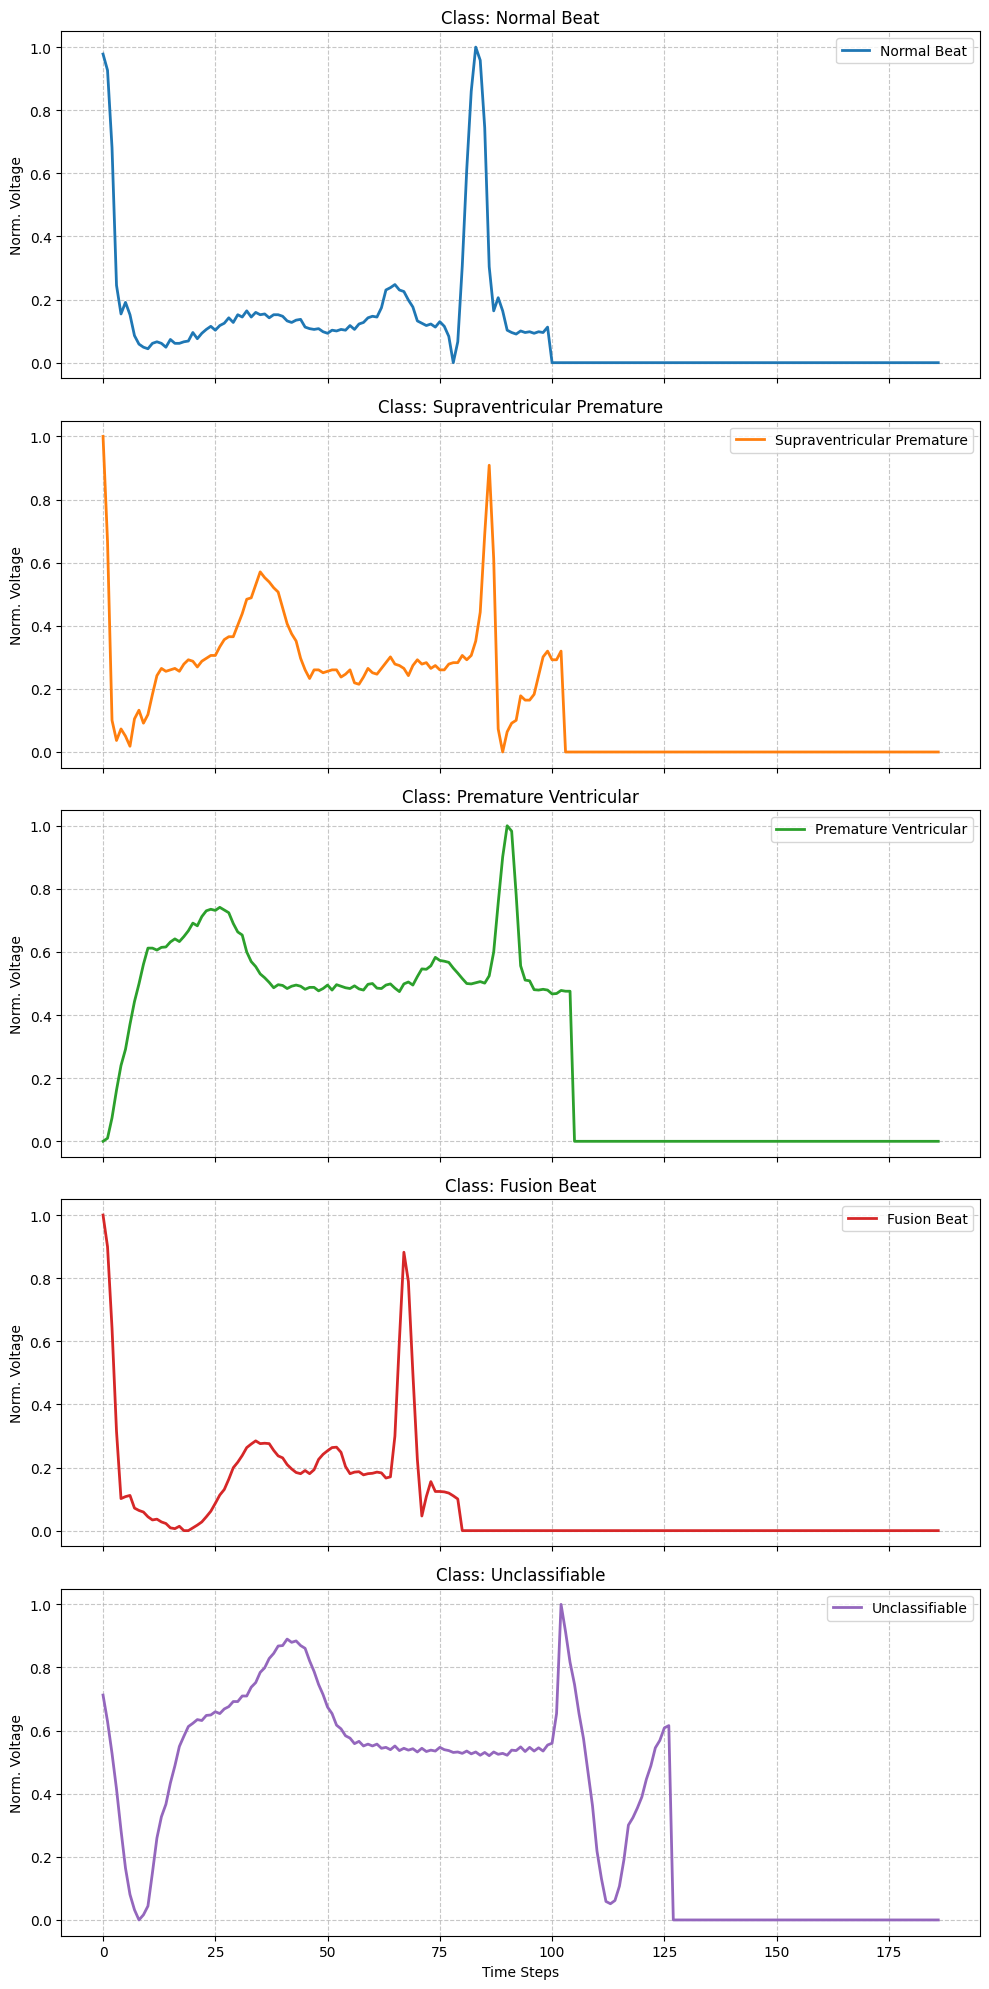

In [108]:
fig, axes = plt.subplots(5, 1, figsize=(10, 20), sharex=True)

for i, (class_val, class_name) in enumerate(class_names.items()):
    # Get the first sample belonging to the current class
    sample = df[df[187] == class_val].iloc[0, :187] 
    
    # Plot on the specific subplot axis
    axes[i].plot(sample, label=class_name, color=f'C{i}', linewidth=2)
    
    axes[i].set_title(f'Class: {class_name}')
    axes[i].set_ylabel('Norm. Voltage')
    axes[i].grid(True, linestyle='--', alpha=0.7)
    axes[i].legend(loc='upper right')

plt.xlabel('Time Steps')
plt.tight_layout()
plt.show()

In [109]:
# 1. Check Scaling
features = df.iloc[:, :-1].values # all columns except label
print(f"Dataset Global Minimum: {features.min():.4f}")
print(f"Dataset Global Maximum: {features.max():.4f}")

Dataset Global Minimum: 0.0000
Dataset Global Maximum: 1.0000


In [110]:
# Check label distribution
class_counts = df[187].value_counts().sort_index()
for class_val, count in class_counts.items():
    percentage = (count / len(df)) * 100
    print(f"Class {int(class_val)} ({class_names[class_val]}): {count} samples ({percentage:.2f}%)")

Class 0 (Normal Beat): 72471 samples (82.77%)
Class 1 (Supraventricular Premature): 2223 samples (2.54%)
Class 2 (Premature Ventricular): 5788 samples (6.61%)
Class 3 (Fusion Beat): 641 samples (0.73%)
Class 4 (Unclassifiable): 6431 samples (7.35%)


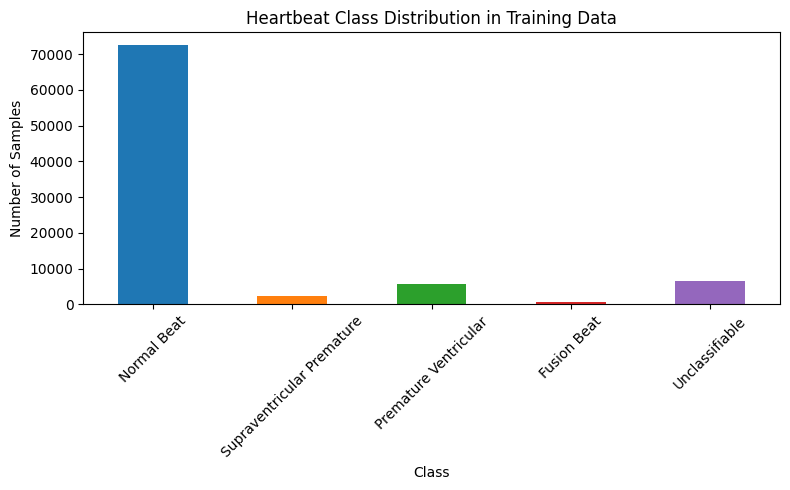

In [111]:
plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color=['C0', 'C1', 'C2', 'C3', 'C4'])
plt.title('Heartbeat Class Distribution in Training Data')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(ticks=range(5), labels=[class_names[i] for i in range(5)], rotation=45)
plt.tight_layout()
plt.show()

There is a big class imbalance, which we will fix by balancing the loss function (penalizing wrong prediction on the smaller labels)

### PART 1 & 2

In [112]:
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

In [113]:
# Hyperparameters
BATCH_SIZE = 64
NUM_FEATURES = 1
HIDDEN_SIZE = 32     
NUM_LAYERS = 3
NUM_CLASSES = 5      
EPOCHS = 20
LEARNING_RATE = 0.0001

In [114]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [115]:
def load_data(csv_file):
    print(f"Loading data from {csv_file}")
    data = pd.read_csv(csv_file, header=None).values
    
    # Split into Features (X) and Labels (y)
    X = data[:, :-1].astype(np.float32) # take all columns except the last
    y = data[:, -1].astype(np.int64)    # only take the last column
    X_tensor = torch.tensor(X)
    y_tensor = torch.tensor(y)
    
    # Reshape from (Samples, 187) to (Samples, 187, 1)
    X_tensor = X_tensor.unsqueeze(-1)
    
    return TensorDataset(X_tensor, y_tensor)

In [116]:
def get_gradient_norm(model):
    # Track gradient to prove they are vanishing or not
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2) # Calculate the L2 norm
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5

In [117]:
def train_model(model, criterion, train_loader, val_loader, optimizer, epochs):
    train_losses, val_losses = [], []
    grad_norm_history = []

    print("Training phase")
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        # Training
        for batches, labels in train_loader:
            batches, labels = batches.to(device), labels.to(device)
            optimizer.zero_grad()
            # Forward Pass
            outputs = model(batches)
            # Compute Loss
            loss = criterion(outputs, labels)
            # Backward Pass (Compute Gradients)
            loss.backward()
            # track gradients
            grad_norm = get_gradient_norm(model)
            grad_norm_history.append(grad_norm)
            # Update weights
            optimizer.step()
            running_train_loss += loss.item()
            
        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # VALIDATION
        model.eval()
        running_val_loss = 0.0
        all_val_preds, all_val_labels = [], []
        
        with torch.no_grad():
            for batches, labels in val_loader:
                batches, labels = batches.to(device), labels.to(device)
                
                outputs = model(batches)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                
                # Get the predicted class (the one with the highest logit score)
                _, predicted = torch.max(outputs.data, 1)
                
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())
                
        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        # Calculate our defined metric: Macro F1-Score
        val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')
        
        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} ; Val Loss: {avg_val_loss:.4f} ; Val Macro F1: {val_f1:.4f}")
    return train_losses, val_losses, grad_norm_history

In [118]:
full_train_dataset = load_data('mitbih_train.csv')
test_dataset = load_data('mitbih_test.csv')

Loading data from mitbih_train.csv


Loading data from mitbih_test.csv


In [119]:
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, (train_size, val_size))

In [120]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [121]:
print("Making sure the shapes match")

# Grab exactly one batch from the training data
sample_seqs, _ = next(iter(train_loader))

# Expected: (Batch Size, 187 Timesteps, 1 Feature)
(BATCH_SIZE, 187, NUM_FEATURES)

Making sure the shapes match


(64, 187, 1)

In [122]:
y_train = df[187].values
class_weights = compute_class_weight(
        class_weight='balanced', 
        classes=np.unique(y_train), 
        y=y_train
    )

In [123]:
tensor_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
tensor_weights

tensor([ 0.2416,  7.8771,  3.0254, 27.3179,  2.7229], device='cuda:0')

In [124]:
class ECG_RNN(nn.Module):
    def __init__(self, num_features, hidden_size, num_layers, num_classes):
        super(ECG_RNN, self).__init__()
        
        # hidden size doesn't need to match the number of timesteps.
        # it means that at every single timestep, the RNN maintains a list of exactly hidden_size numbers.
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # The RNN Layer
        # batch_first=True means the input tensor is shaped (batch_size, Timesteps, Features), but the features is just 1 since we recorded only Voltage.
        
        # ACTIVATION FUNCTION: By default, PyTorch's nn.RNN uses tanh at each time step to compute the hidden state. 
        # This non-linearity squashes internal values between -1 and 1, which helps prevent exploding gradients 
        # as the model multiplies weights across all 187 time steps.
        self.rnn = nn.RNN(num_features, hidden_size, num_layers, batch_first=True)
        
        # The Output Layer
        # This converts the 1D tensor of the RNN hidden layer output into raw logits.
        # (Note: Softmax is applied automatically later by the CrossEntropyLoss function).
        self.output = nn.Linear(hidden_size, num_classes)        
    def forward(self, x):
        # Initialize the hidden state with zeros
        # Shape: (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate through the RNN
        # out shape: (batch_size, Timesteps, hidden_size)
        out, _ = self.rnn(x, h0)
        
        # Keep all batches and hidden numbers, but only look at the last timestep to use for prediction.
        final_out = out[:, -1, :] 
        
        # Pass the final hidden state to the fully connected layer
        # Output shape: (batch_size, num_classes)
        
        return self.output(final_out) 

In [125]:
class ECG_LSTM(nn.Module):
    def __init__(self, num_features, hidden_size, num_layers, num_classes):
        super(ECG_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(num_features, hidden_size, num_layers, batch_first=True)
        self.output = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        # LSTM requires BOTH a hidden state (h0) and a cell state (c0)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        final_out = out[:, -1, :] 
        return self.output(final_out)

In [126]:
class ECG_GRU(nn.Module):
    def __init__(self, num_features, hidden_size, num_layers, num_classes):
        super(ECG_GRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Using nn.GRU. It combines the forget and input gates into a single "update gate"
        self.gru = nn.GRU(num_features, hidden_size, num_layers, batch_first=True)
        self.output = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.gru(x, h0)
        final_out = out[:, -1, :] 
        return self.output(final_out)

In [127]:
# Initialize RNN Model, Loss, and Optimizer
model_rnn = ECG_RNN(NUM_FEATURES, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(weight=tensor_weights)
optimizer_rnn = optim.Adam(model_rnn.parameters(), lr=LEARNING_RATE)

In [128]:
train_losses_rnn, val_losses_rnn, grad_norm_history_rnn = train_model(model_rnn, criterion, train_loader, val_loader, optimizer_rnn, EPOCHS)

Training phase
Epoch 1: Train Loss: 1.6001 ; Val Loss: 1.5995 ; Val Macro F1: 0.1868
Epoch 2: Train Loss: 1.5843 ; Val Loss: 1.5631 ; Val Macro F1: 0.1012
Epoch 3: Train Loss: 1.5229 ; Val Loss: 1.7319 ; Val Macro F1: 0.0510
Epoch 4: Train Loss: 1.3188 ; Val Loss: 1.2465 ; Val Macro F1: 0.2291
Epoch 5: Train Loss: 1.2578 ; Val Loss: 1.3009 ; Val Macro F1: 0.1900
Epoch 6: Train Loss: 1.2359 ; Val Loss: 1.2247 ; Val Macro F1: 0.2254
Epoch 7: Train Loss: 1.2228 ; Val Loss: 1.2296 ; Val Macro F1: 0.2353
Epoch 8: Train Loss: 1.2205 ; Val Loss: 1.2334 ; Val Macro F1: 0.2120
Epoch 9: Train Loss: 1.2173 ; Val Loss: 1.2058 ; Val Macro F1: 0.2419
Epoch 10: Train Loss: 1.2056 ; Val Loss: 1.2191 ; Val Macro F1: 0.2465
Epoch 11: Train Loss: 1.2103 ; Val Loss: 1.2905 ; Val Macro F1: 0.2195
Epoch 12: Train Loss: 1.1985 ; Val Loss: 1.2148 ; Val Macro F1: 0.2375
Epoch 13: Train Loss: 1.2010 ; Val Loss: 1.1962 ; Val Macro F1: 0.2637
Epoch 14: Train Loss: 1.1976 ; Val Loss: 1.2198 ; Val Macro F1: 0.2387


Testing Phase
FINAL TEST MACRO F1-SCORE: 0.2575


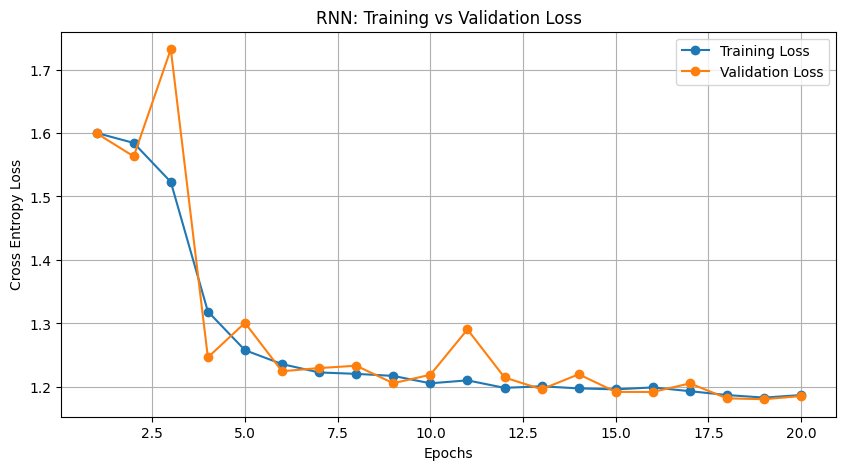

In [129]:
print("Testing Phase")
model_rnn.eval()
all_test_preds_rnn, all_test_labels_rnn = [], []
with torch.no_grad():
    for batches, labels in test_loader:
        batches, labels = batches.to(device), labels.to(device)
        outputs = model_rnn(batches)
        _, predicted = torch.max(outputs.data, 1)
        all_test_preds_rnn.extend(predicted.cpu().numpy())
        all_test_labels_rnn.extend(labels.cpu().numpy())

test_f1 = f1_score(all_test_labels_rnn, all_test_preds_rnn, average='macro')
print(f"FINAL TEST MACRO F1-SCORE: {test_f1:.4f}")

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), train_losses_rnn, label='Training Loss', marker='o')
plt.plot(range(1, EPOCHS+1), val_losses_rnn, label='Validation Loss', marker='o')
plt.title('RNN: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

The Macro F1-score for the basic RNN seems to be very low.

This can be due to the vanishing gradient problem since we have 187 time steps. The repeated multiplication of weights through the standard tanh activation causes the learning gradients to shrink to near zero.

Plus, as we can see, the training and validation loss seem to converge around 1.53, and they didn't decrease much from the initial 1.60.


Without the ability to remember the full temporal structure of the heartbeat, the model fails to differentiate between imbalanced classes.

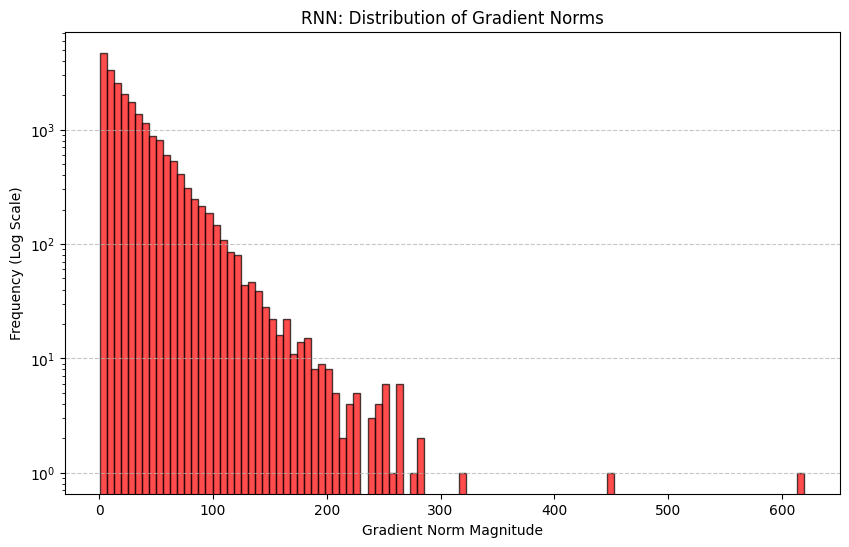

In [130]:
plt.figure(figsize=(10, 6))
plt.hist(grad_norm_history_rnn, bins=100, color='red', alpha=0.7, edgecolor='black')
plt.yscale('log') 
plt.title('RNN: Distribution of Gradient Norms')
plt.xlabel('Gradient Norm Magnitude')
plt.ylabel('Frequency (Log Scale)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [131]:
# Initialize LSTM Model, Loss, and Optimizer
model_lstm = ECG_LSTM(NUM_FEATURES, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES).to(device)
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE)

In [132]:
train_losses_lstm, val_losses_lstm, grad_norm_history_lstm = train_model(model_lstm, criterion, train_loader, val_loader, optimizer_lstm, EPOCHS)

Training phase
Epoch 1: Train Loss: 1.6014 ; Val Loss: 1.6010 ; Val Macro F1: 0.1810
Epoch 2: Train Loss: 1.5995 ; Val Loss: 1.6005 ; Val Macro F1: 0.1810
Epoch 3: Train Loss: 1.5684 ; Val Loss: 1.4363 ; Val Macro F1: 0.0670
Epoch 4: Train Loss: 1.3226 ; Val Loss: 1.2480 ; Val Macro F1: 0.2732
Epoch 5: Train Loss: 1.2318 ; Val Loss: 1.2917 ; Val Macro F1: 0.2281
Epoch 6: Train Loss: 1.2001 ; Val Loss: 1.2005 ; Val Macro F1: 0.2693
Epoch 7: Train Loss: 1.1714 ; Val Loss: 1.1594 ; Val Macro F1: 0.2955
Epoch 8: Train Loss: 1.1742 ; Val Loss: 1.1978 ; Val Macro F1: 0.2887
Epoch 9: Train Loss: 1.1620 ; Val Loss: 1.1640 ; Val Macro F1: 0.2892
Epoch 10: Train Loss: 1.1711 ; Val Loss: 1.1778 ; Val Macro F1: 0.2520
Epoch 11: Train Loss: 1.1521 ; Val Loss: 1.1301 ; Val Macro F1: 0.3126
Epoch 12: Train Loss: 1.1290 ; Val Loss: 1.1875 ; Val Macro F1: 0.2959
Epoch 13: Train Loss: 1.1591 ; Val Loss: 1.1797 ; Val Macro F1: 0.2753
Epoch 14: Train Loss: 1.1241 ; Val Loss: 1.1061 ; Val Macro F1: 0.3097


Testing Phase
FINAL TEST MACRO F1-SCORE: 0.3066


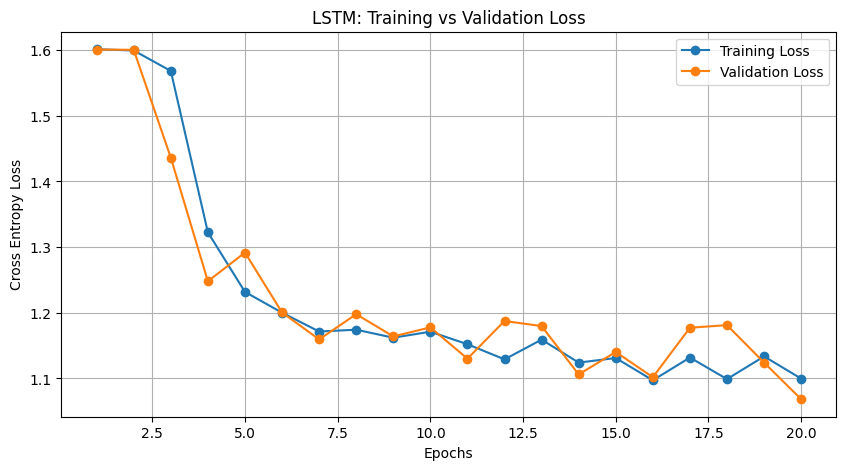

In [133]:
print("Testing Phase")
model_lstm.eval()
all_test_preds_lstm, all_test_labels_lstm = [], []
with torch.no_grad():
    for batches, labels in test_loader:
        batches, labels = batches.to(device), labels.to(device)
        outputs = model_lstm(batches)
        _, predicted = torch.max(outputs.data, 1)
        all_test_preds_lstm.extend(predicted.cpu().numpy())
        all_test_labels_lstm.extend(labels.cpu().numpy())

test_f1 = f1_score(all_test_labels_lstm, all_test_preds_lstm, average='macro')
print(f"FINAL TEST MACRO F1-SCORE: {test_f1:.4f}")

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), train_losses_lstm, label='Training Loss', marker='o')
plt.plot(range(1, EPOCHS+1), val_losses_lstm, label='Validation Loss', marker='o')
plt.title('LSTM: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

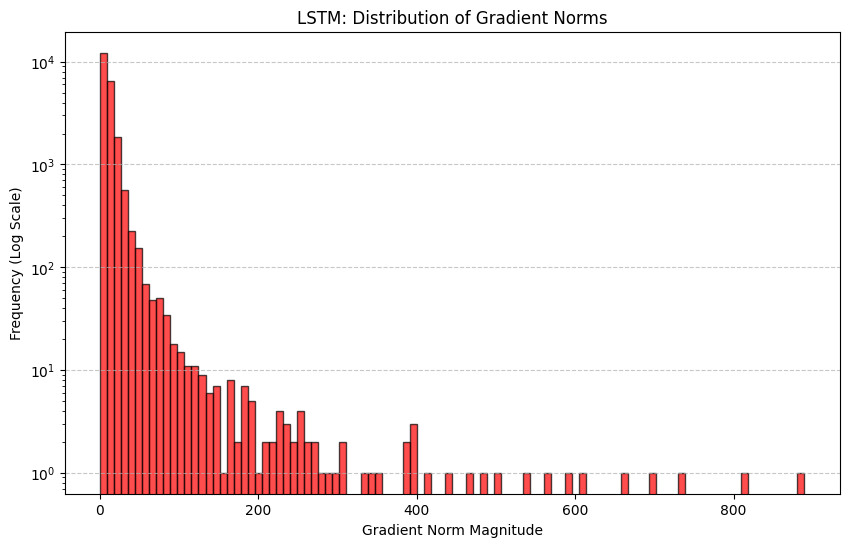

In [134]:
plt.figure(figsize=(10, 6))
plt.hist(grad_norm_history_lstm, bins=100, color='red', alpha=0.7, edgecolor='black')
plt.yscale('log') 
plt.title('LSTM: Distribution of Gradient Norms')
plt.xlabel('Gradient Norm Magnitude')
plt.ylabel('Frequency (Log Scale)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [135]:
model_gru = ECG_GRU(NUM_FEATURES, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES).to(device)
optimizer_gru = optim.Adam(model_gru.parameters(), lr=LEARNING_RATE)

In [136]:
train_losses_gru, val_losses_gru, grad_norm_history_gru = train_model(model_gru, criterion, train_loader, val_loader, optimizer_gru, EPOCHS)

Training phase
Epoch 1: Train Loss: 1.6000 ; Val Loss: 1.5991 ; Val Macro F1: 0.1948
Epoch 2: Train Loss: 1.5860 ; Val Loss: 1.5673 ; Val Macro F1: 0.2114
Epoch 3: Train Loss: 1.5472 ; Val Loss: 1.5177 ; Val Macro F1: 0.1118
Epoch 4: Train Loss: 1.3637 ; Val Loss: 1.2882 ; Val Macro F1: 0.1935
Epoch 5: Train Loss: 1.2551 ; Val Loss: 1.2446 ; Val Macro F1: 0.2541
Epoch 6: Train Loss: 1.2252 ; Val Loss: 1.2513 ; Val Macro F1: 0.2396
Epoch 7: Train Loss: 1.2066 ; Val Loss: 1.2052 ; Val Macro F1: 0.2529
Epoch 8: Train Loss: 1.1961 ; Val Loss: 1.1972 ; Val Macro F1: 0.2643
Epoch 9: Train Loss: 1.1863 ; Val Loss: 1.1814 ; Val Macro F1: 0.2904
Epoch 10: Train Loss: 1.1756 ; Val Loss: 1.1854 ; Val Macro F1: 0.2672
Epoch 11: Train Loss: 1.1666 ; Val Loss: 1.1642 ; Val Macro F1: 0.2980
Epoch 12: Train Loss: 1.1529 ; Val Loss: 1.1506 ; Val Macro F1: 0.2951
Epoch 13: Train Loss: 1.1410 ; Val Loss: 1.1377 ; Val Macro F1: 0.3086
Epoch 14: Train Loss: 1.1204 ; Val Loss: 1.1357 ; Val Macro F1: 0.3034


Testing Phase
FINAL TEST MACRO F1-SCORE: 0.3271


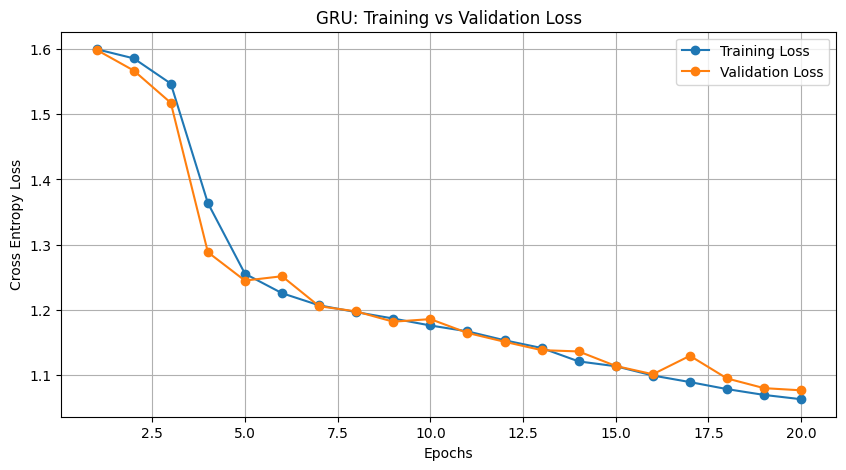

In [137]:
print("Testing Phase")
model_gru.eval()
all_test_preds_gru, all_test_labels_gru = [], []
with torch.no_grad():
    for batches, labels in test_loader:
        batches, labels = batches.to(device), labels.to(device)
        outputs = model_gru(batches)
        _, predicted = torch.max(outputs.data, 1)
        all_test_preds_gru.extend(predicted.cpu().numpy())
        all_test_labels_gru.extend(labels.cpu().numpy())

test_f1 = f1_score(all_test_labels_gru, all_test_preds_gru, average='macro')
print(f"FINAL TEST MACRO F1-SCORE: {test_f1:.4f}")

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), train_losses_gru, label='Training Loss', marker='o')
plt.plot(range(1, EPOCHS+1), val_losses_gru, label='Validation Loss', marker='o')
plt.title('GRU: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

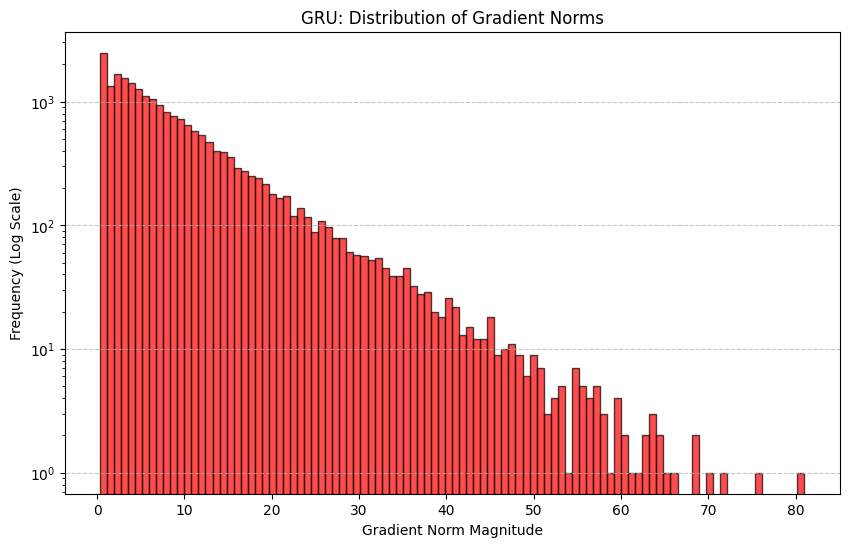

In [138]:
plt.figure(figsize=(10, 6))
plt.hist(grad_norm_history_gru, bins=100, color='red', alpha=0.7, edgecolor='black')
plt.yscale('log') 
plt.title('GRU: Distribution of Gradient Norms')
plt.xlabel('Gradient Norm Magnitude')
plt.ylabel('Frequency (Log Scale)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Overall, we can see the LSTM and the GRU are performing better than the RNN.

The training loss and validation loss seem to be both decreasing gradually, while the RNN's losses seem to be converging.

The LSTM and the GRU also yielded a higher F1 macro score.

In the histogram of the gradient norms, we can see the GRU allowed for a better distribution of gradient norms compared to the LSTM and the RNN, so it's suffering much less from vanishing gradient problems.

However, all 3 models are still underfitting. It seems 187 steps is still a long sequence for a 3-layer network.

Plus, since the Macro F1 metric averages the score of all 5 classes equally. Failing on just one rare class (e.g., class 3 which makes up 0.73% of the data) tanks the entire score.

### PART 3


A traditional feed-forward network can be used for this problem, however an MLP processes all inputs simultaneously and independently, it has no concept sequence. Therefore, to use an MLP, we would need to manually engineer features that capture the time dependency such as rolling averages and wave durations, to explicitly give the model a sense of time.

## TASK 3

### Part 1


**Choice of pre-trained word embedding model:** BERT
**Reason**: In Word2Vec/GloVe, if a word isn't in their dictionnary, they are ignored. In contrast, BERT solves the OOV problem by breaking down unknown words into known subwords.
**OOV Handling Strategy**: Using the Hugging face tokenizer, after the unknown word is split into sub-word pieces, we'll approximate the full word's embedding by extracting the vector for each subword and calculating the mean.

In [ ]:
from transformers import AutoTokenizer, AutoModel

In [4]:
# Load model using Hugging Face
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
def get_embedding(word):
    word = word.lower().strip()
    # Tokenize the word. Unknown words are automatically split into subwords.
    # return_tensors="pt" formats the output for PyTorch.
    tokens = tokenizer(word, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**tokens)
    
    # Extract the hidden states. 
    # Shape is (batch_size, sequence_length, hidden_size).
    # We slice [0, 1:-1, :] to drop the artificial [CLS] and [SEP] start/end tokens.
    subword_vectors = outputs.last_hidden_state[0, 1:-1, :]
    
    # If it's a known word, it averages 1 vector (no change). 
    # If OOV, it averages the subword pieces.
    final_embedding = subword_vectors.mean(dim=0)
    
    # Print a warning if OOV subword splitting occurred
    num_subwords = subword_vectors.shape[0]
    if num_subwords > 1:
         print(f"OOV Warning for '{word}'")
         print(f"Approximated by averaging its {num_subwords} subwords.")

    return final_embedding

In [23]:
word1 = "lie"
word2 = "april"
word3 = "YourLieInApril"
vec1 = get_embedding(word1)
vec2 = get_embedding(word2)
vec3 = get_embedding(word3)

OOV Warning for 'yourlieinapril'
Approximated by averaging its 5 subwords.


In [24]:
vec1.shape

torch.Size([768])

In [25]:
vec2.shape

torch.Size([768])

In [26]:
vec3.shape

torch.Size([768])

In [27]:
vec1[:10]

tensor([ 0.3620, -0.2760,  0.1360, -0.2446,  0.4035,  0.0945,  0.3457, -0.1851,
         0.5145, -0.5166])

In [28]:
vec2[:10]

tensor([-0.8915,  0.1926,  0.0073, -0.4952, -0.0788,  0.1369,  0.2859,  0.5814,
        -0.1251, -0.2348])

In [29]:
vec3[:10]

tensor([-0.2268,  0.1404,  0.1999, -0.0488,  0.1180,  0.2398,  0.0838,  0.1495,
        -0.0381, -0.2219])

### Part 2

Cosine similarity measures the angle between two vectors rather than their Euclidean distance.

A word's vector embedding magnitude (length) often increases based on how frequently it appeared in the training dataset.

Therefore cosine similarity ensures that a rare word and a common word can still be identified as similar as long as they share similar meanings.



In [44]:
def compute_cosine_similarity(vec1, vec2):
    return torch.nn.functional.cosine_similarity(vec1.unsqueeze(0), vec2.unsqueeze(0)).item()

In [45]:
# Calculate Cosine Similarity
cos_sim = compute_cosine_similarity(vec1, vec2)
print(f"Cosine Similarity betwen {word1} and {word2}: {cos_sim:.4f}")

Cosine Similarity betwen lie and april: 0.5033


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA

In [46]:
batch_pairs = [
    ("Your", "Name"),
    ("Look", "Back"),
    ("Chainsaw", "Man"),
    ("Attack", "Titan")
]

In [47]:
for w1, w2 in batch_pairs:
    v1 = get_embedding(w1)
    v2 = get_embedding(w2)
    sim = compute_cosine_similarity(v1, v2)
    print(f"Similarity ('{w1}', '{w2}'): {sim:.4f}")

Similarity ('Your', 'Name'): 0.6831
Similarity ('Look', 'Back'): 0.6686
OOV Warning for 'chainsaw'
Approximated by averaging its 2 subwords.
Similarity ('Chainsaw', 'Man'): 0.5272
Similarity ('Attack', 'Titan'): 0.6641


In [58]:
words_to_plot = [
    "April", "March", "December", "June", # Cluster 1
    "Drama", "Psychological", "Action", "Romance", # Cluster 2
    "Blue", "Red", "Violet", "Gojo" # Cluster 3
]

In [59]:
embeddings = []
for word in words_to_plot:
    embeddings.append(get_embedding(word).numpy())
embeddings_matrix = np.array(embeddings)

OOV Warning for 'gojo'
Approximated by averaging its 2 subwords.


In [60]:
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_matrix)

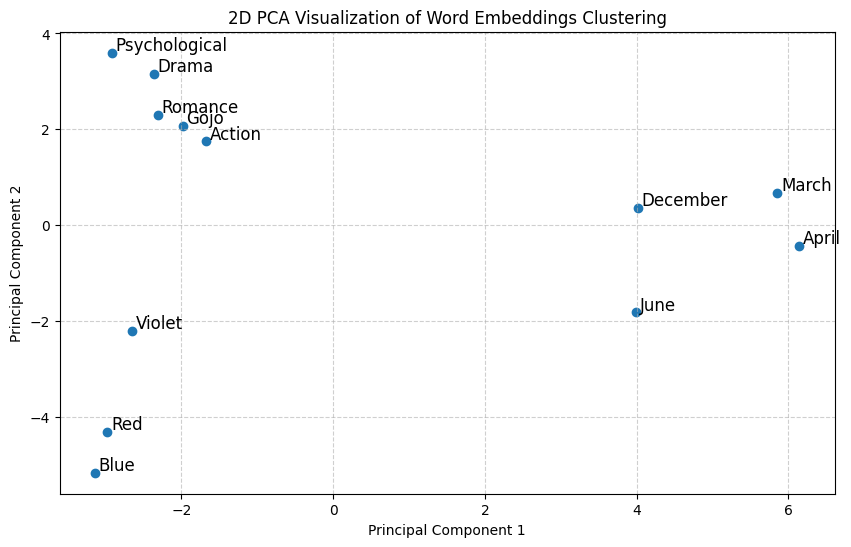

In [61]:
plt.figure(figsize=(10, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])
for i, word in enumerate(words_to_plot):
    plt.annotate(word, (embeddings_2d[i, 0] + 0.05, embeddings_2d[i, 1] + 0.05), fontsize=12)

plt.title("2D PCA Visualization of Word Embeddings Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Part 3

We will implement Euclidean Distance as a dissimilarity metric.

If two words mean the same thing but one is rare and the other is common, cosine similarity will treat them as similar, when Euclidean Distance will tream them as dissimilar.

In [63]:
def compare_words(vec1, vec2, metric):
    if metric == "cosine":
        return compute_cosine_similarity(vec1, vec2)
    else:
        # Returns Dissimilarity Distance (Lower = more similar, min 0.0)
        return torch.dist(vec1, vec2, p=2).item()

In [64]:
target_word = "Titan"
comparison_words = ["Colossal", "Armor", "Attack", "Female", "Beast", "Cart", "Jaw", "War", "Hammer", "Founding"]

target_vec = get_embedding(target_word)
cos_scores, euc_scores = [], []

for w in comparison_words:
    v = get_embedding(w)
    cos_scores.append(compare_words(target_vec, v, "cosine"))
    euc_scores.append(compare_words(target_vec, v, "euclidean"))

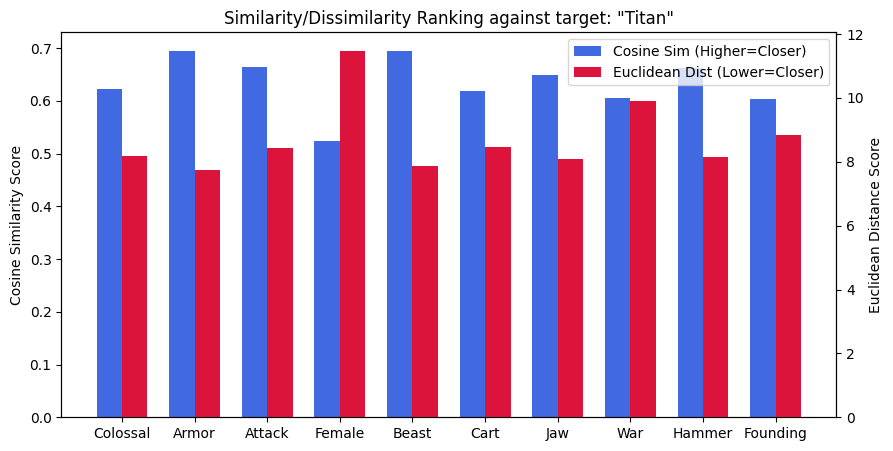

In [70]:
x = np.arange(len(comparison_words))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

# Cosine (Higher is better)
rects1 = ax1.bar(x - width/2, cos_scores, width, label='Cosine Sim (Higher=Closer)', color='royalblue')
# Euclidean (Lower is better)
rects2 = ax2.bar(x + width/2, euc_scores, width, label='Euclidean Dist (Lower=Closer)', color='crimson')

ax1.set_ylabel('Cosine Similarity Score')
ax2.set_ylabel('Euclidean Distance Score')
ax1.set_title(f'Similarity/Dissimilarity Ranking against target: "{target_word}"')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_words)

# Combine legends
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, loc='upper right')
plt.show()

In [80]:
heatmap_words = ["Envy", "Sloth", "Greed", "Gluttony", "Pride", "Wrath", "Lust"] # FMA Brotherhood or Rezero
n = len(heatmap_words)

# Initialize empty matrices
cos_matrix = np.zeros((n, n))
euc_matrix = np.zeros((n, n))

# Fill the matrices
for i in range(n):
    v1 = get_embedding(heatmap_words[i])
    for j in range(n):
        v2 = get_embedding(heatmap_words[j])
        cos_matrix[i, j] = compare_words(v1, v2, "cosine")
        euc_matrix[i, j] = compare_words(v1, v2, "euclidean")

OOV Warning for 'sloth'
Approximated by averaging its 2 subwords.
OOV Warning for 'gluttony'
Approximated by averaging its 4 subwords.
OOV Warning for 'sloth'
Approximated by averaging its 2 subwords.
OOV Warning for 'sloth'
Approximated by averaging its 2 subwords.
OOV Warning for 'gluttony'
Approximated by averaging its 4 subwords.
OOV Warning for 'sloth'
Approximated by averaging its 2 subwords.
OOV Warning for 'gluttony'
Approximated by averaging its 4 subwords.
OOV Warning for 'gluttony'
Approximated by averaging its 4 subwords.
OOV Warning for 'sloth'
Approximated by averaging its 2 subwords.
OOV Warning for 'gluttony'
Approximated by averaging its 4 subwords.
OOV Warning for 'sloth'
Approximated by averaging its 2 subwords.
OOV Warning for 'gluttony'
Approximated by averaging its 4 subwords.
OOV Warning for 'sloth'
Approximated by averaging its 2 subwords.
OOV Warning for 'gluttony'
Approximated by averaging its 4 subwords.
OOV Warning for 'sloth'
Approximated by averaging its 2

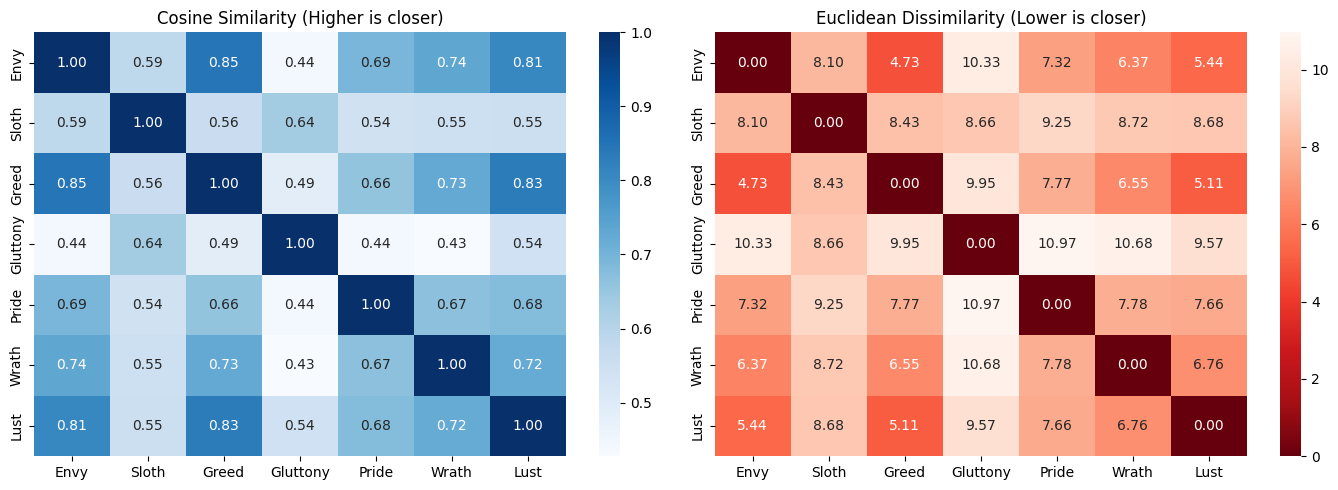

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cos_matrix, annot=True, xticklabels=heatmap_words, yticklabels=heatmap_words, 
            cmap="Blues", ax=axes[0], fmt=".2f")
axes[0].set_title("Cosine Similarity (Higher is closer)")

sns.heatmap(euc_matrix, annot=True, xticklabels=heatmap_words, yticklabels=heatmap_words, 
            cmap="Reds_r", ax=axes[1], fmt=".2f") # Reversed colormap so dark = closer
axes[1].set_title("Euclidean Dissimilarity (Lower is closer)")

plt.tight_layout()
plt.show()